# Árvores de regressão 

*Atenção! Devido descontinuação da base de imóveis boston os alunos devem utilizar a base de dados que se encontra em anexo.*

A base que utilizaremos contem os dados dos imóveis da california.
Considerem como variável Target (a ser prevista) a coluna median_house_value.
O dataset é muito semelhante ao de boston, contendo localização, quartos, banheiros e outras variáveis interessantes para construção do modelo.

In [ ]:
import pandas as pd

import seaborn as sns

from sklearn import datasets
from sklearn.tree import DecisionTreeRegressor
from sklearn import tree
from sklearn.model_selection import train_test_split



### 1. Certifique-se de que esta base está no formato adequado para o scikitlearn.
ok, essa tarefa é tão fácil que você vai até desconfiar. Mas é preciso ter confiança sobre os dados que se usa ;)

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import mean_squared_error



# carregar a base
df = pd.read_csv('housing.csv')

# visualizar estrutura
print(df.head())
print(df.info())
print(df.isna().sum())

# remover valores ausentes
df = df.dropna()

# transformar variável categórica em numérica
df = pd.get_dummies(df, columns=['ocean_proximity'], drop_first=True)

print(df.head())
print(df.info())

   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   
3    -122.25     37.85                52.0       1274.0           235.0   
4    -122.25     37.85                52.0       1627.0           280.0   

   population  households  median_income  median_house_value ocean_proximity  
0       322.0       126.0         8.3252            452600.0        NEAR BAY  
1      2401.0      1138.0         8.3014            358500.0        NEAR BAY  
2       496.0       177.0         7.2574            352100.0        NEAR BAY  
3       558.0       219.0         5.6431            341300.0        NEAR BAY  
4       565.0       259.0         3.8462            342200.0        NEAR BAY  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639

### 2.  Visualize a matriz de correlação, e veja se aparentemente você encontra alguma variável com potencial preditivo interessante.

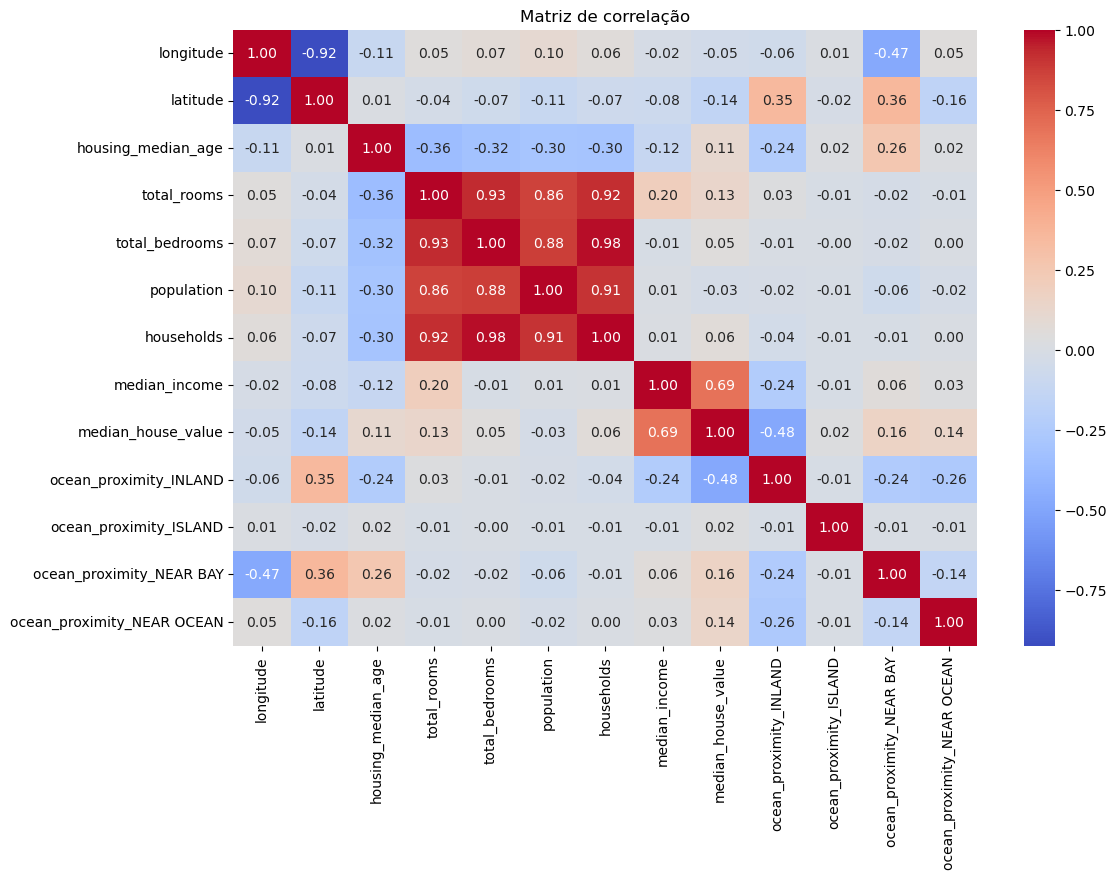

In [2]:
plt.close('all')

corr = df.corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de correlação')
plt.show()

### 3. Separe os dados em validação e teste

In [3]:
X = df.drop('median_house_value', axis=1)
y = df['median_house_value']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

### 4. Treine duas árvores, uma com profundidade máxima = 8, outra com profundidade máxima = 2.

In [4]:
arvore_8 = DecisionTreeRegressor(max_depth=8, random_state=42)
arvore_2 = DecisionTreeRegressor(max_depth=2, random_state=42)

arvore_8.fit(X_train, y_train)
arvore_2.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=2, random_state=42)

### 5. Calcule o MSE de cada uma das árvores do item anterior para a base de treinamento e para a base de testes.

In [5]:
# previsões
y_pred_train_8 = arvore_8.predict(X_train)
y_pred_test_8 = arvore_8.predict(X_test)

y_pred_train_2 = arvore_2.predict(X_train)
y_pred_test_2 = arvore_2.predict(X_test)

# mse
mse_train_8 = mean_squared_error(y_train, y_pred_train_8)
mse_test_8 = mean_squared_error(y_test, y_pred_test_8)

mse_train_2 = mean_squared_error(y_train, y_pred_train_2)
mse_test_2 = mean_squared_error(y_test, y_pred_test_2)

print('Árvore profundidade 8')
print('MSE treino:', mse_train_8)
print('MSE teste :', mse_test_8)

print('\nÁrvore profundidade 2')
print('MSE treino:', mse_train_2)
print('MSE teste :', mse_test_2)

Árvore profundidade 8
MSE treino: 3147421826.84027
MSE teste : 3945094742.228483

Árvore profundidade 2
MSE treino: 6717879487.782716
MSE teste : 6786496172.207578


### 6. Com base nos resultados do item anterior, qual árvore te parece mais adequada?

Comparando os resultados, a árvore com profundidade máxima igual a 8 parece mais adequada. Ela apresentou erro menor tanto na base de treinamento quanto na base de teste. A árvore com profundidade 2 ficou muito simples e não conseguiu capturar tão bem os padrões dos dados.

### 7. Faça uma visualização gráfica dessa árvore. Vamos discutir importância de variável mais adiante, mas veja a sua árvore, e pense um pouco: qual variável te parece mais "importante" na árvore?

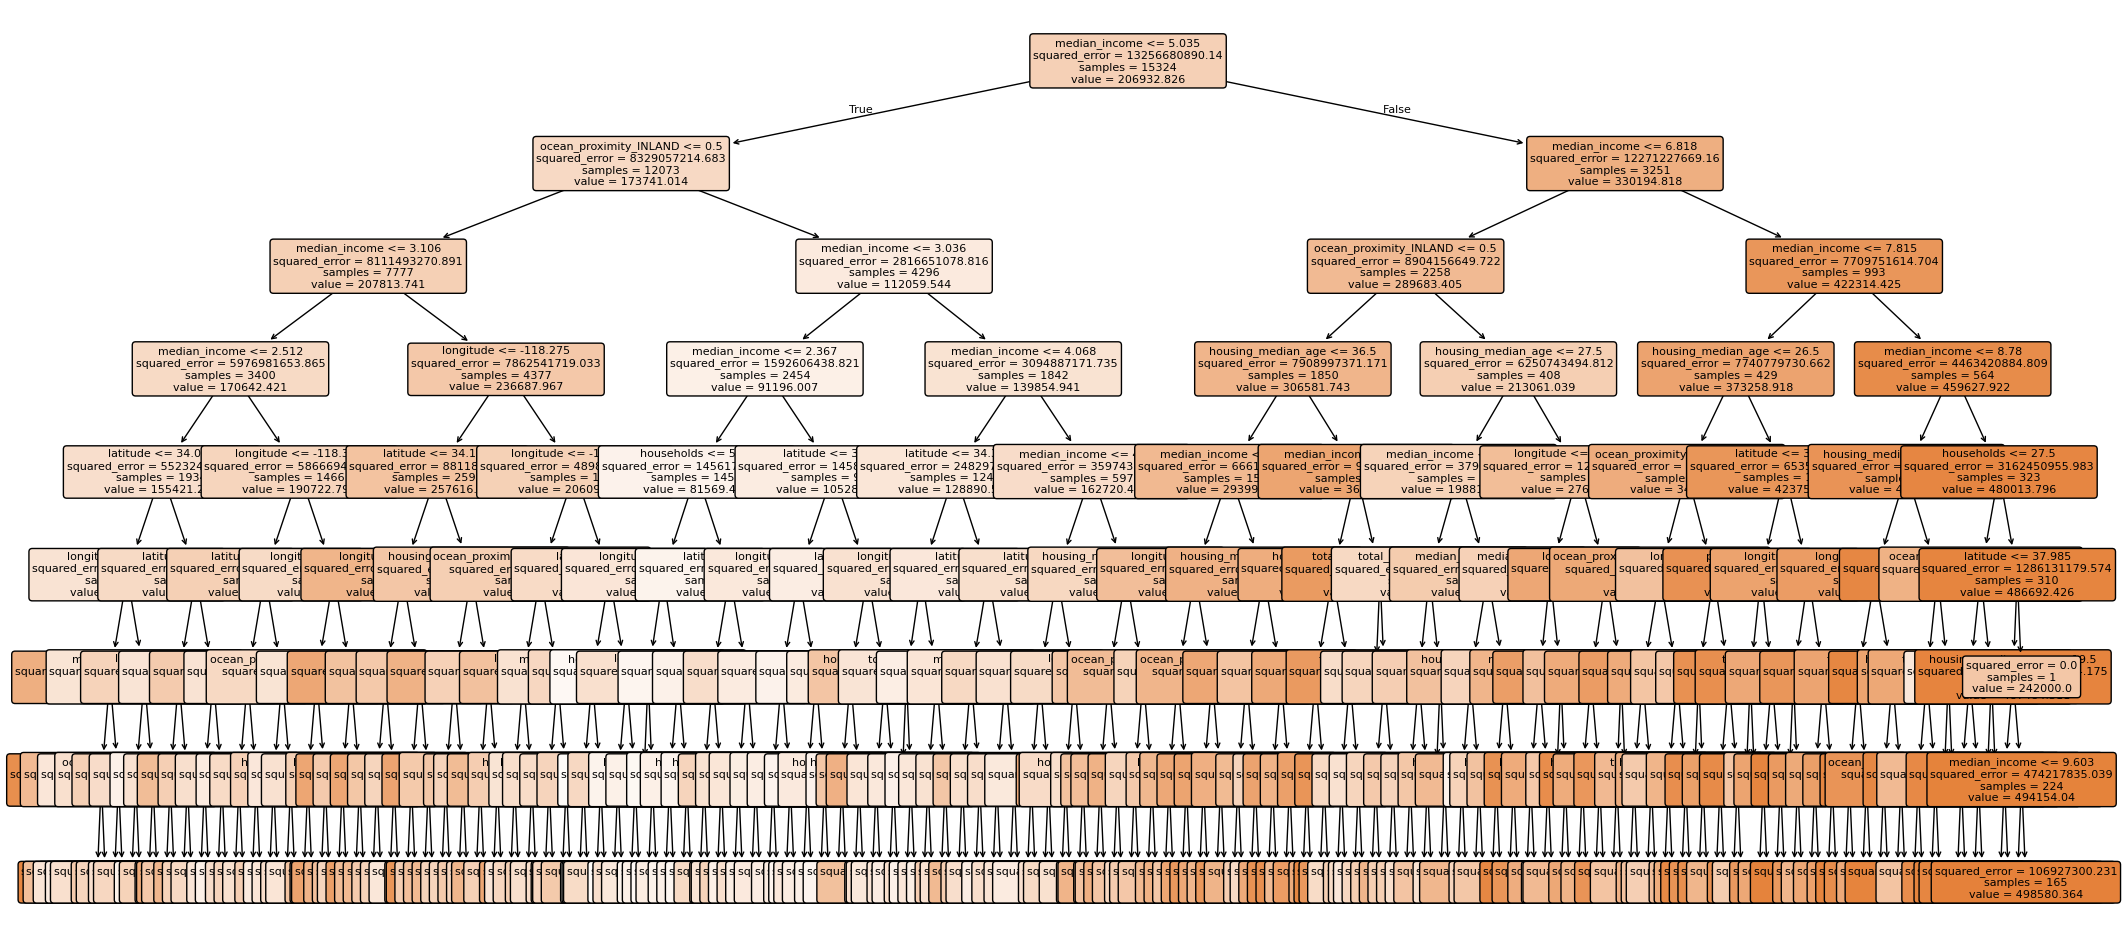

In [6]:
plt.close('all')

plt.figure(figsize=(25,12))
plot_tree(
    arvore_8,
    feature_names=X.columns,
    filled=True,
    rounded=True,
    fontsize=8
)
plt.show()

Observando a árvore, a variável que parece mais importante é median_income, pois ela aparece logo nas primeiras divisões. Isso indica que a renda mediana da região tem forte influência no valor mediano dos imóveis.